In [1]:
import pandas as pd
import scimap as sm
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import json
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind, ttest_rel
warnings.filterwarnings("ignore")

Running SCIMAP  2.3.1


/Users/lukashat/miniforge3/envs/scimap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

# PC nbhs wiht bone

In [4]:
adata.obs

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM


In [3]:
conditions = [
    adata.obs['distance_to_bone_corrected'] <= 20,
    (adata.obs['distance_to_bone_corrected'] > 20) & (adata.obs['distance_to_bone_corrected'] < 50),
    adata.obs['distance_to_bone_corrected'] >= 50
]

choices = ['adjacent', 'intermediate', 'distant']
adata.obs['bone_niches'] = np.select(conditions, choices, default=np.nan)
adata.obs['bone_niches'] = adata.obs['bone_niches'].replace('nan', np.nan)
adata.obs

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,bone_niches
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM,intermediate
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM,distant
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM,distant
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM,distant
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM,distant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM,distant
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM,distant
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM,distant
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM,distant


In [4]:
adata = adata[~adata.obs['bone_niches'].isna()]

In [5]:
radius = 20
sm.tl.spatial_count(adata, x_coordinate='X_centroid', y_coordinate='Y_centroid', phenotype='Phenotype4', method='radius', radius=radius, imageid='image_ID', verbose=True, label='spatial_count') 

Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours within 20 pixels of every cell
Identifying neighbours withi

AnnData object with n_obs × n_vars = 868344 × 33
    obs: 'Object', 'area', 'Y_centroid', 'X_centroid', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'distance_to_bone', 'image_ID', 'disease', 'patient_ID', 'ROI', 'disease2', 'distance_to_bone_corrected', 'cellcharter_CN', 'Phenotype4', 'HistoneH3', 'disease3', 'bone_niches'
    var: 'name', 'channel', 'deepcell', 'mean', 'std'
    uns: 'Phenotype4_colors', 'cellcharter_CN_colors', 'spatial', 'spatial_neighbors', 'spatial_count'
    obsm: 'spatial'
    layers: 'arcsinh', 'zscore'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [6]:
disease_mapping = adata.obs[['disease2', 'image_ID']].drop_duplicates()
disease_mapping.set_index('image_ID', inplace=True)

In [9]:
adata.uns['spatial_count']

neighbour_phenotype,Adipocytes,CD4 T,CD8 T,Endothelial,HLA-DR+ Macs/monos,HSPCs,MPO+,Macs/monos,Neutrophils,OB/RUNX2+,Osteoclasts,Osteocytes,PCs,Unknown,DCs
Object 1 in TS-373_IMC77_B_001.csv,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.400000,0.0,0.0,0.0,0.000000,0.600000,0.0
Object 2 in TS-373_IMC77_B_001.csv,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
Object 3 in TS-373_IMC77_B_001.csv,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.400000,0.0,0.0,0.0,0.000000,0.600000,0.0
Object 4 in TS-373_IMC77_B_001.csv,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.555556,0.0,0.0,0.0,0.000000,0.444444,0.0
Object 5 in TS-373_IMC77_B_001.csv,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.555556,0.0,0.0,0.0,0.000000,0.444444,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,0.0,0.000000,0.272727,0.000000,0.181818,0.0,0.0,0.090909,0.454545,0.0,0.0,0.0,0.000000,0.000000,0.0
Object 6623 in TS-373_IMC83_B_001.csv,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.916667,0.0,0.0,0.0,0.083333,0.000000,0.0
Object 6624 in TS-373_IMC83_B_001.csv,0.0,0.166667,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.666667,0.0,0.0,0.0,0.166667,0.000000,0.0
Object 6625 in TS-373_IMC83_B_001.csv,0.0,0.200000,0.000000,0.000000,0.100000,0.0,0.0,0.000000,0.300000,0.0,0.0,0.0,0.300000,0.100000,0.0


In [7]:
df = adata.uns['spatial_count']
df['Phenotype4'] = adata.obs['Phenotype4']
df['image_ID'] = adata.obs['image_ID']
df['bone_niches'] = adata.obs['bone_niches']
df['image_ID'] = df['image_ID'].astype(str)
df = df[df['Phenotype4'] == 'PCs']
df = df.drop(columns=['Phenotype4'])
df = df.groupby(['image_ID', 'bone_niches']).mean()
df = df.reset_index()
df

neighbour_phenotype,image_ID,bone_niches,Adipocytes,CD4 T,CD8 T,Endothelial,HLA-DR+ Macs/monos,HSPCs,MPO+,Macs/monos,Neutrophils,OB/RUNX2+,Osteoclasts,Osteocytes,PCs,Unknown,DCs
0,TS-373_IMC01_UB_001.csv,adjacent,0.006018,0.013410,0.026815,0.033843,0.094697,0.043239,0.130738,0.043038,0.201557,0.006460,0.0,0.037324,0.192929,0.165236,0.004698
1,TS-373_IMC01_UB_001.csv,distant,0.005533,0.014073,0.023613,0.020903,0.084468,0.022095,0.077777,0.062387,0.302795,0.001984,0.0,0.000000,0.194268,0.178931,0.011171
2,TS-373_IMC01_UB_001.csv,intermediate,0.010888,0.021822,0.031167,0.024495,0.099398,0.023154,0.095201,0.053722,0.249880,0.002396,0.0,0.000000,0.197975,0.173715,0.016188
3,TS-373_IMC01_UB_002.csv,adjacent,0.019375,0.009497,0.012929,0.033762,0.069797,0.034589,0.132801,0.010888,0.139654,0.008604,0.0,0.039082,0.227160,0.205582,0.056281
4,TS-373_IMC01_UB_002.csv,distant,0.009584,0.023039,0.032503,0.026367,0.084848,0.022283,0.066042,0.046420,0.199062,0.000187,0.0,0.000000,0.310728,0.154872,0.018556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,TS-373_IMC95_B_001.csv,distant,0.015137,0.002667,0.013237,0.009616,0.028750,0.004363,0.070662,0.110122,0.440762,0.002876,0.0,0.000000,0.131549,0.162364,0.000376
399,TS-373_IMC95_B_001.csv,intermediate,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.416667,0.061111,0.0,0.000000,0.061111,0.377778,0.000000
400,TS-373_IMC96_B_001.csv,adjacent,0.000000,0.002331,0.007887,0.049400,0.157847,0.032854,0.091445,0.025880,0.212275,0.042243,0.0,0.010664,0.179224,0.187949,0.000000
401,TS-373_IMC96_B_001.csv,distant,0.018416,0.010281,0.018373,0.016203,0.097015,0.014767,0.072328,0.049940,0.264115,0.002111,0.0,0.000000,0.151862,0.277285,0.005765


In [8]:
df_melted = df.melt(
    id_vars=['image_ID', 'bone_niches'],
    var_name='neighbour_phenotype',
    value_name='fraction_of_cells'
)
df_melted['disease2'] = df_melted['image_ID'].map(disease_mapping['disease2'])
df_melted

,image_ID,bone_niches,neighbour_phenotype,fraction_of_cells,disease2
0,TS-373_IMC01_UB_001.csv,adjacent,Adipocytes,0.006018,MM_noBD
1,TS-373_IMC01_UB_001.csv,distant,Adipocytes,0.005533,MM_noBD
2,TS-373_IMC01_UB_001.csv,intermediate,Adipocytes,0.010888,MM_noBD
3,TS-373_IMC01_UB_002.csv,adjacent,Adipocytes,0.019375,MM_noBD
4,TS-373_IMC01_UB_002.csv,distant,Adipocytes,0.009584,MM_noBD
...,...,...,...,...,...
6040,TS-373_IMC95_B_001.csv,distant,DCs,0.000376,MM_BD
6041,TS-373_IMC95_B_001.csv,intermediate,DCs,0.000000,MM_BD
6042,TS-373_IMC96_B_001.csv,adjacent,DCs,0.000000,MM_BD
6043,TS-373_IMC96_B_001.csv,distant,DCs,0.005765,MM_BD


In [9]:
df_melted_MM = df_melted[df_melted['disease2'].isin(['MM_noBD', 'MM_BD'])] 

In [10]:
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
cmap = {
    'adjacent': default_colors[0],
    'intermediate': default_colors[1],
    'distant': default_colors[2]
}
order = ['adjacent', 'intermediate', 'distant']

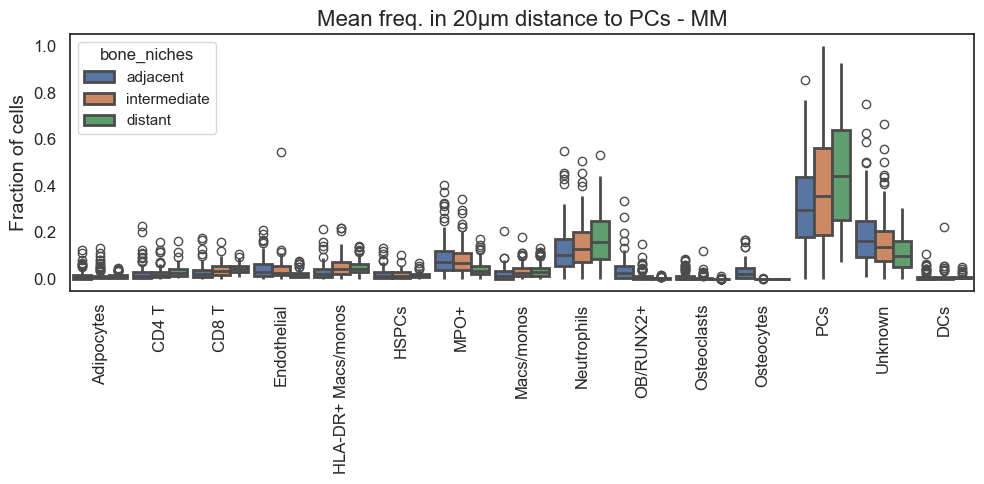

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', hue_order=order, palette=cmap, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - MM', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_all_diseases.{extension}'), bbox_inches='tight')


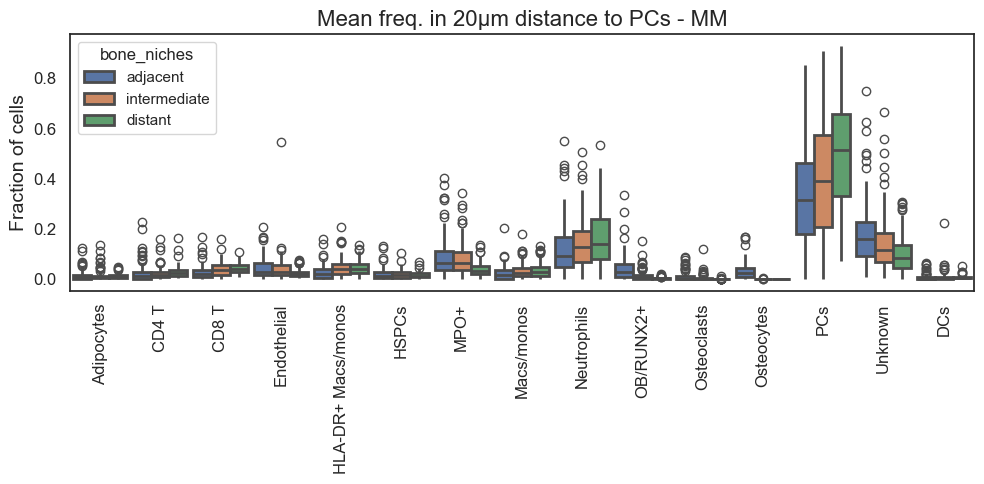

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted_MM, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', hue_order=order, palette=cmap, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - MM', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_MM.{extension}'), bbox_inches='tight')


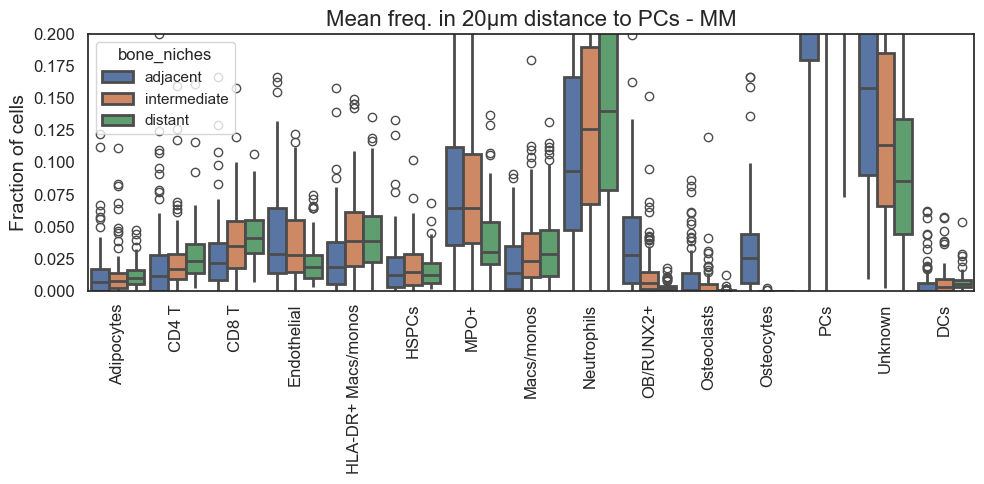

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted_MM, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', hue_order=order, palette=cmap, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - MM', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 0.2)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_MM_ylim.{extension}'), bbox_inches='tight')


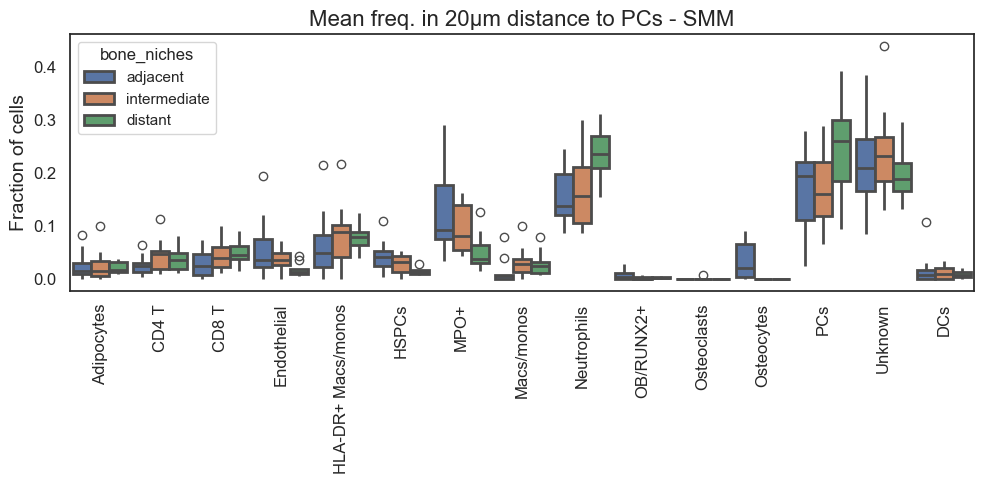

In [16]:
df_melted_SMM = df_melted[df_melted['disease2'].isin(["SMM"])]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted_SMM, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', hue_order=order, palette=cmap, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - SMM', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_SMM.{extension}'), bbox_inches='tight')


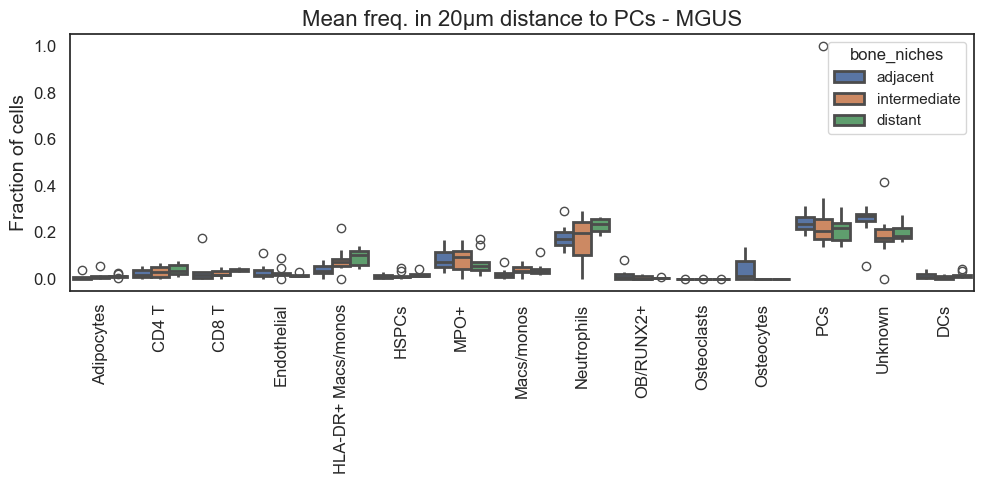

In [17]:
df_melted_MGUS = df_melted[df_melted['disease2'].isin(["MGUS"])]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted_MGUS, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches',palette=cmap, hue_order=order, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - MGUS', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_MGUS.{extension}'), bbox_inches='tight')

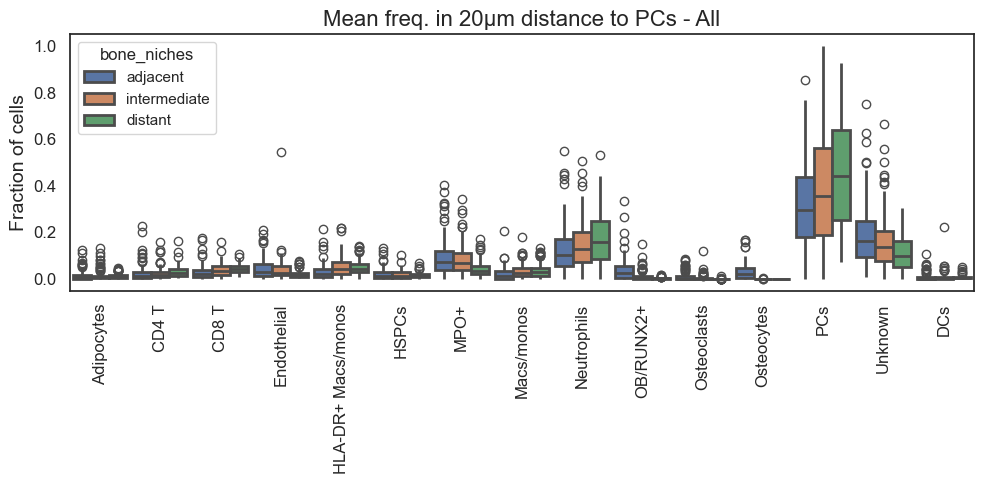

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', palette=cmap, hue_order=order, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - All', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_all.{extension}'), bbox_inches='tight')


In [19]:
df.columns

Index(['image_ID', 'bone_niches', 'Adipocytes', 'CD4 T', 'CD8 T',
       'Endothelial', 'HLA-DR+ Macs/monos', 'HSPCs', 'MPO+', 'Macs/monos',
       'Neutrophils', 'OB/RUNX2+', 'Osteoclasts', 'Osteocytes', 'PCs',
       'Unknown', 'DCs'],
      dtype='object', name='neighbour_phenotype')

In [20]:
df_melted_MM_BD = df_melted[df_melted['disease2'].isin(['MM_BD'])]
df_melted_MM_noBD = df_melted[df_melted['disease2'].isin(['MM_noBD'])]

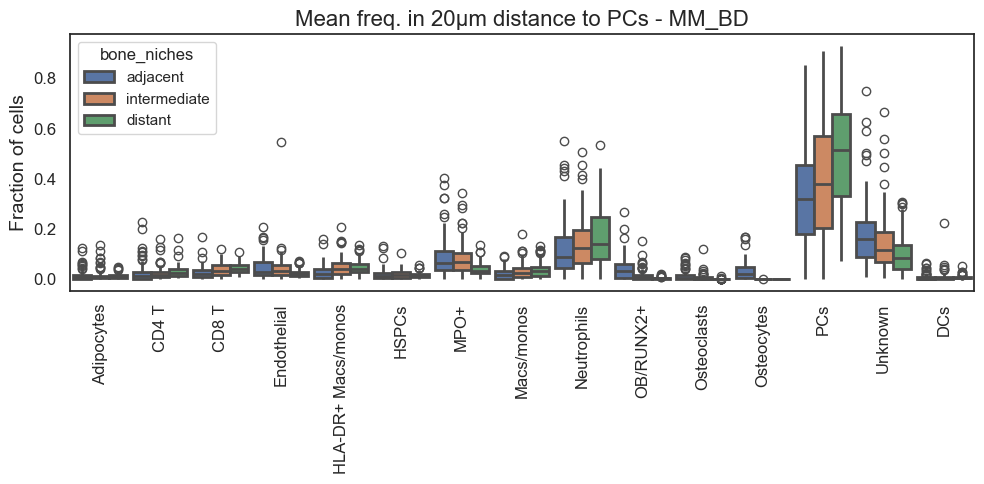

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted_MM_BD, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', palette=cmap, hue_order=order, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - MM_BD', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_MM_BD.{extension}'), bbox_inches='tight')

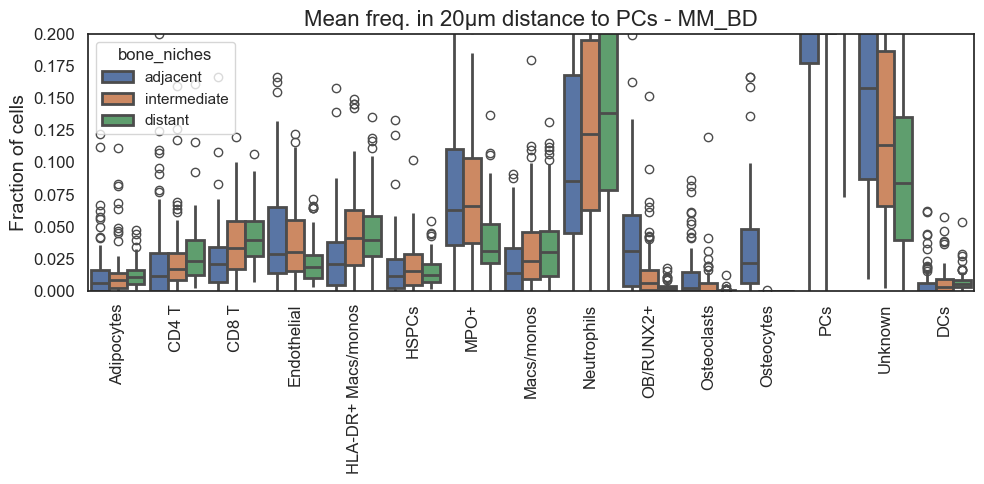

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted_MM_BD, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', palette=cmap, hue_order=order, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - MM_BD', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 0.2)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_MM_BD_ylim.{extension}'), bbox_inches='tight')

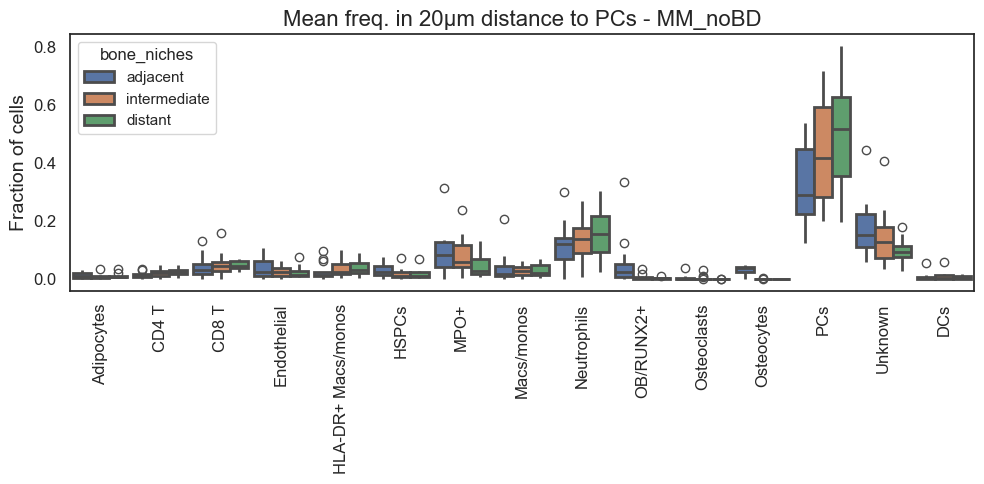

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted_MM_noBD, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', palette=cmap, hue_order=order, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - MM_noBD', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_MM_noBD.{extension}'), bbox_inches='tight')

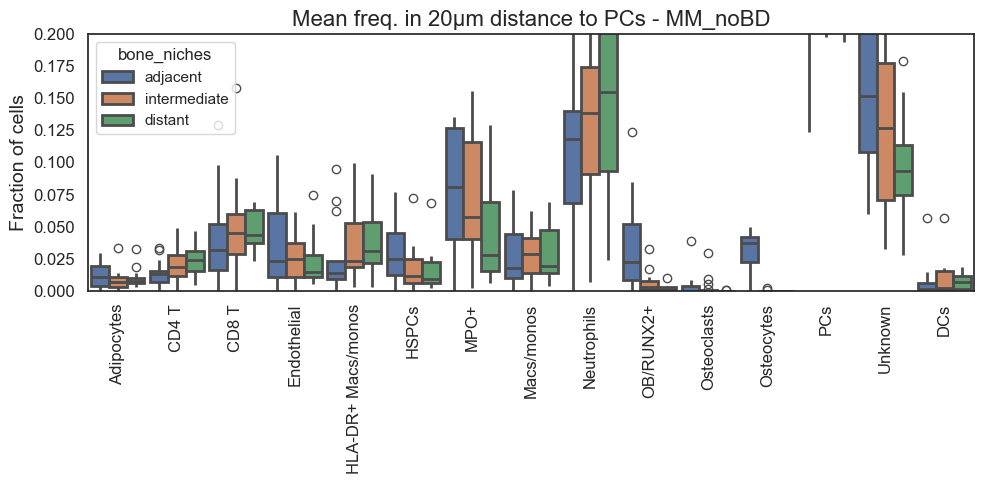

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted_MM_noBD, x='neighbour_phenotype', y='fraction_of_cells', hue='bone_niches', palette=cmap, hue_order=order, ax=ax, showcaps=False, linewidth=2, width=0.9)
plt.xticks(rotation=90)
plt.title(f'Mean freq. in 20µm distance to PCs - MM_noBD', fontsize=16)
plt.ylabel('Fraction of cells', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 0.2)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhood_freq_MM_noBD_ylim.{extension}'), bbox_inches='tight')

# Bone distance NBHs

In [25]:
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")

In [26]:
adata.obs

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM


In [27]:
disease_mapping

,disease2
image_ID,
TS-373_IMC77_B_001.csv,MM_BD
TS-373_IMC03_MGUS_002.csv,MGUS
TS-373_IMC04_MGUS_002.csv,MGUS
TS-373_IMC12_UB_001.csv,MM_noBD
TS-373_IMC86_B_002.csv,MM_BD
...,...
TS-373_IMC16-1_MGUS_002.csv,SMM
TS-373_IMC66_B_002.csv,MM_BD
TS-373_IMC53_B_002.csv,MM_BD


In [28]:
df = pd.crosstab(adata.obs['image_ID'], adata.obs['cellcharter_CN'], values=adata.obs['distance_to_bone_corrected'], aggfunc='mean').reset_index()

df_melted = df.melt(
    id_vars=['image_ID'],
    var_name='cellcharter_CN',
    value_name='distance_to_bone_corrected'
)
df_melted.dropna(inplace=True)
df_melted['disease2'] = df_melted['image_ID'].map(disease_mapping['disease2'])
df_melted

,image_ID,cellcharter_CN,distance_to_bone_corrected,disease2
0,TS-373_IMC01_UB_001.csv,ADAPTIVE_IMMUNE,62.046716,MM_noBD
1,TS-373_IMC01_UB_002.csv,ADAPTIVE_IMMUNE,79.012173,MM_noBD
2,TS-373_IMC02_MGUS_001.csv,ADAPTIVE_IMMUNE,481.911194,MGUS
3,TS-373_IMC02_MGUS_002.csv,ADAPTIVE_IMMUNE,103.570185,MGUS
4,TS-373_IMC03_MGUS_001.csv,ADAPTIVE_IMMUNE,128.991322,MGUS
...,...,...,...,...
1210,TS-373_IMC92_B_001.csv,PROLIF_GLYC,244.993750,MM_BD
1211,TS-373_IMC93_B_001.csv,PROLIF_GLYC,384.064843,MM_BD
1212,TS-373_IMC93_B_002.csv,PROLIF_GLYC,361.840041,MM_BD
1213,TS-373_IMC95_B_001.csv,PROLIF_GLYC,337.393091,MM_BD


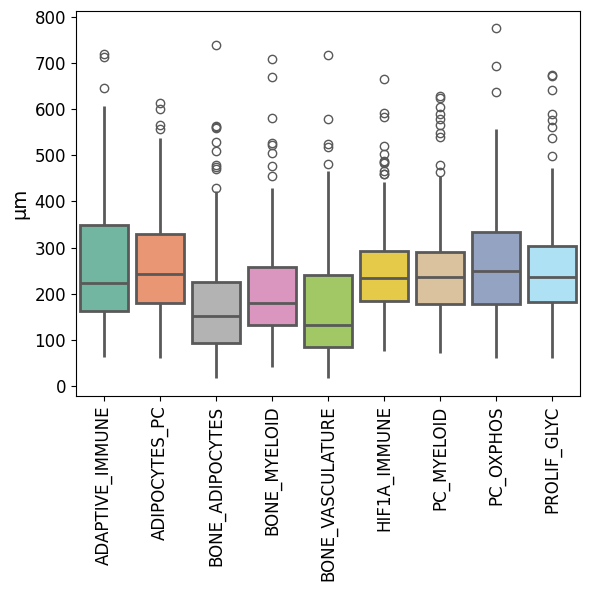

In [29]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(6, 6))
sns.boxplot(data=df_melted, x='cellcharter_CN', y='distance_to_bone_corrected', palette=neighborhood_color_map, showcaps=False, linewidth=2, width=0.85)
plt.xlabel('')
plt.ylabel('µm', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_neighborhoods_bone_distances.{extension}'), bbox_inches='tight')

In [36]:
pc_oxphos = df_melted[df_melted['cellcharter_CN'] == 'PC_OXPHOS']['distance_to_bone_corrected']
pc_myeloid = df_melted[df_melted['cellcharter_CN'] == 'PC_MYELOID']['distance_to_bone_corrected']
stats, p = ttest_ind(pc_oxphos, pc_myeloid)
p

0.33340973593820644

# Freq among PC_NBHs

In [125]:
df = adata.obs[['image_ID', 'cellcharter_CN', 'Phenotype4', 'disease']]
df

,image_ID,cellcharter_CN,Phenotype4,disease
Object 1 in TS-373_IMC77_B_001.csv,TS-373_IMC77_B_001.csv,ADIPOCYTES_PC,PCs,MM_BD
Object 2 in TS-373_IMC77_B_001.csv,TS-373_IMC77_B_001.csv,BONE_ADIPOCYTES,Unknown,MM_BD
Object 3 in TS-373_IMC77_B_001.csv,TS-373_IMC77_B_001.csv,HIF1A_IMMUNE,Neutrophils,MM_BD
Object 4 in TS-373_IMC77_B_001.csv,TS-373_IMC77_B_001.csv,ADIPOCYTES_PC,Unknown,MM_BD
Object 5 in TS-373_IMC77_B_001.csv,TS-373_IMC77_B_001.csv,PC_MYELOID,Unknown,MM_BD
...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,TS-373_IMC83_B_001.csv,HIF1A_IMMUNE,Neutrophils,MM_BD
Object 6623 in TS-373_IMC83_B_001.csv,TS-373_IMC83_B_001.csv,PC_MYELOID,CD4 T,MM_BD
Object 6624 in TS-373_IMC83_B_001.csv,TS-373_IMC83_B_001.csv,BONE_MYELOID,Neutrophils,MM_BD
Object 6625 in TS-373_IMC83_B_001.csv,TS-373_IMC83_B_001.csv,PC_MYELOID,HLA-DR+ Macs/monos,MM_BD


In [196]:
df = pd.crosstab([adata.obs['image_ID'], adata.obs['Phenotype4']], adata.obs['cellcharter_CN'], normalize='index')

In [197]:
df = df.reset_index()
df = df[df['Phenotype4'] == 'PCs'].drop(columns=['Phenotype4'])
df

cellcharter_CN,image_ID,ADAPTIVE_IMMUNE,ADIPOCYTES_PC,BONE_ADIPOCYTES,BONE_MYELOID,BONE_VASCULATURE,HIF1A_IMMUNE,PC_MYELOID,PC_OXPHOS,PROLIF_GLYC
12,TS-373_IMC01_UB_001.csv,0.001582,0.052215,0.037975,0.087025,0.229430,0.023734,0.436709,0.047468,0.083861
26,TS-373_IMC01_UB_002.csv,0.049947,0.104145,0.062699,0.048884,0.120085,0.012752,0.411265,0.119022,0.071201
39,TS-373_IMC02_MGUS_001.csv,0.006263,0.107516,0.018789,0.037578,0.011482,0.066806,0.584551,0.036534,0.130480
53,TS-373_IMC02_MGUS_002.csv,0.001639,0.101639,0.054098,0.104918,0.136066,0.029508,0.400000,0.024590,0.147541
67,TS-373_IMC03_MGUS_001.csv,0.003774,0.147170,0.050943,0.098113,0.303774,0.020755,0.269811,0.033962,0.071698
...,...,...,...,...,...,...,...,...,...,...
2140,TS-373_IMC93_B_002.csv,0.009571,0.115273,0.015397,0.057012,0.017894,0.023720,0.339159,0.218061,0.203912
2154,TS-373_IMC95_B_001.csv,0.000000,0.086957,0.072464,0.065217,0.094203,0.021739,0.420290,0.057971,0.181159
2167,TS-373_IMC95_B_002.csv,0.031746,0.047619,0.000000,0.063492,0.007937,0.023810,0.674603,0.031746,0.119048
2181,TS-373_IMC96_B_001.csv,0.017544,0.107962,0.022942,0.086370,0.167341,0.074224,0.400810,0.059379,0.063428


In [198]:
disease3_mapping = adata.obs[['disease3', 'image_ID']].drop_duplicates()
disease3_mapping.set_index('image_ID', inplace=True)

In [199]:
adata.obs

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM


In [200]:
df_melted = df.melt(
    id_vars='image_ID',
    var_name='cellcharter_CN',
    value_name='fraction_of_PCs'
)
df_melted = df_melted[df_melted['cellcharter_CN'].isin(['PC_OXPHOS', 'PC_MYELOID'])]
df_melted['disease'] = df_melted['image_ID'].map(disease3_mapping['disease3'])
df_melted

,image_ID,cellcharter_CN,fraction_of_PCs,disease
912,TS-373_IMC01_UB_001.csv,PC_MYELOID,0.436709,MM
913,TS-373_IMC01_UB_002.csv,PC_MYELOID,0.411265,MM
914,TS-373_IMC02_MGUS_001.csv,PC_MYELOID,0.584551,MGUS
915,TS-373_IMC02_MGUS_002.csv,PC_MYELOID,0.400000,MGUS
916,TS-373_IMC03_MGUS_001.csv,PC_MYELOID,0.269811,MGUS
...,...,...,...,...
1211,TS-373_IMC93_B_002.csv,PC_OXPHOS,0.218061,MM
1212,TS-373_IMC95_B_001.csv,PC_OXPHOS,0.057971,MM
1213,TS-373_IMC95_B_002.csv,PC_OXPHOS,0.031746,MM
1214,TS-373_IMC96_B_001.csv,PC_OXPHOS,0.059379,MM


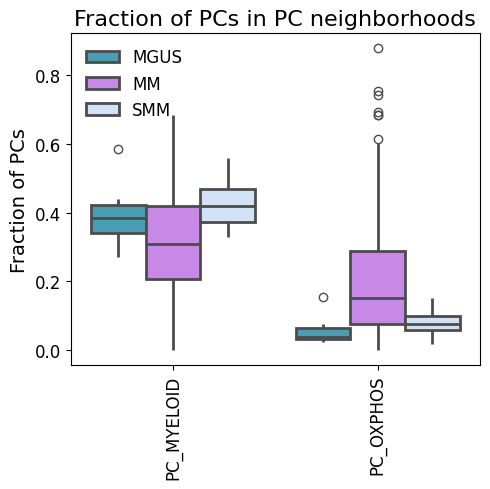

In [217]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df_melted, x='cellcharter_CN', y='fraction_of_PCs', hue='disease', palette=disease3_color_map, ax=ax, showcaps=False, linewidth=2, width=0.8)
plt.xticks(rotation=90)
plt.title(f'Fraction of PCs in PC neighborhoods', fontsize=16)
plt.ylabel('Fraction of PCs', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', title='', fontsize=12, framealpha=0)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'PC_distribution_pc_nbhs.{extension}'), bbox_inches='tight')